In [16]:
import matplotlib.pyplot as plt
from typing import List

In [ ]:
def hash_f(key: int, n: int) -> int:
    return key % n


def visualise_hash_fun(bucket_vars: List[int]):
    keys = [i for i in range(100)]

    buckets_res = {}
    for bv in bucket_vars:
        buckets_res[bv] = [hash_f(i, bv) for i in keys]

    num_plots = len(bucket_vars)
    ncols = 2 if num_plots > 1 else 1
    nrows = (num_plots + ncols - 1) // ncols

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))

    if num_plots == 1:
        axes = [ax]
    else:
        axes = ax.flatten()

    for idx, bv in enumerate(bucket_vars):
        current_ax = axes[idx]
        data = buckets_res[bv]

        bins = [i - 0.5 for i in range(bv + 1)]

        current_ax.hist(data, bins=bins, rwidth=0.8, color="skyblue", edgecolor="black")

        current_ax.set_title(map_title(bv))
        current_ax.set_xticks(range(bv))
        current_ax.set_xlabel("Индекс бакета (Хеш)")
        current_ax.set_ylabel("Количество ключей")
        current_ax.grid(axis="y", linestyle="--", alpha=0.7)

    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    print("Результаты распределения по бакетам:")
    print(buckets_res)


def map_title(bv: int) -> str:
    return f"Распределение для N = {bv}"

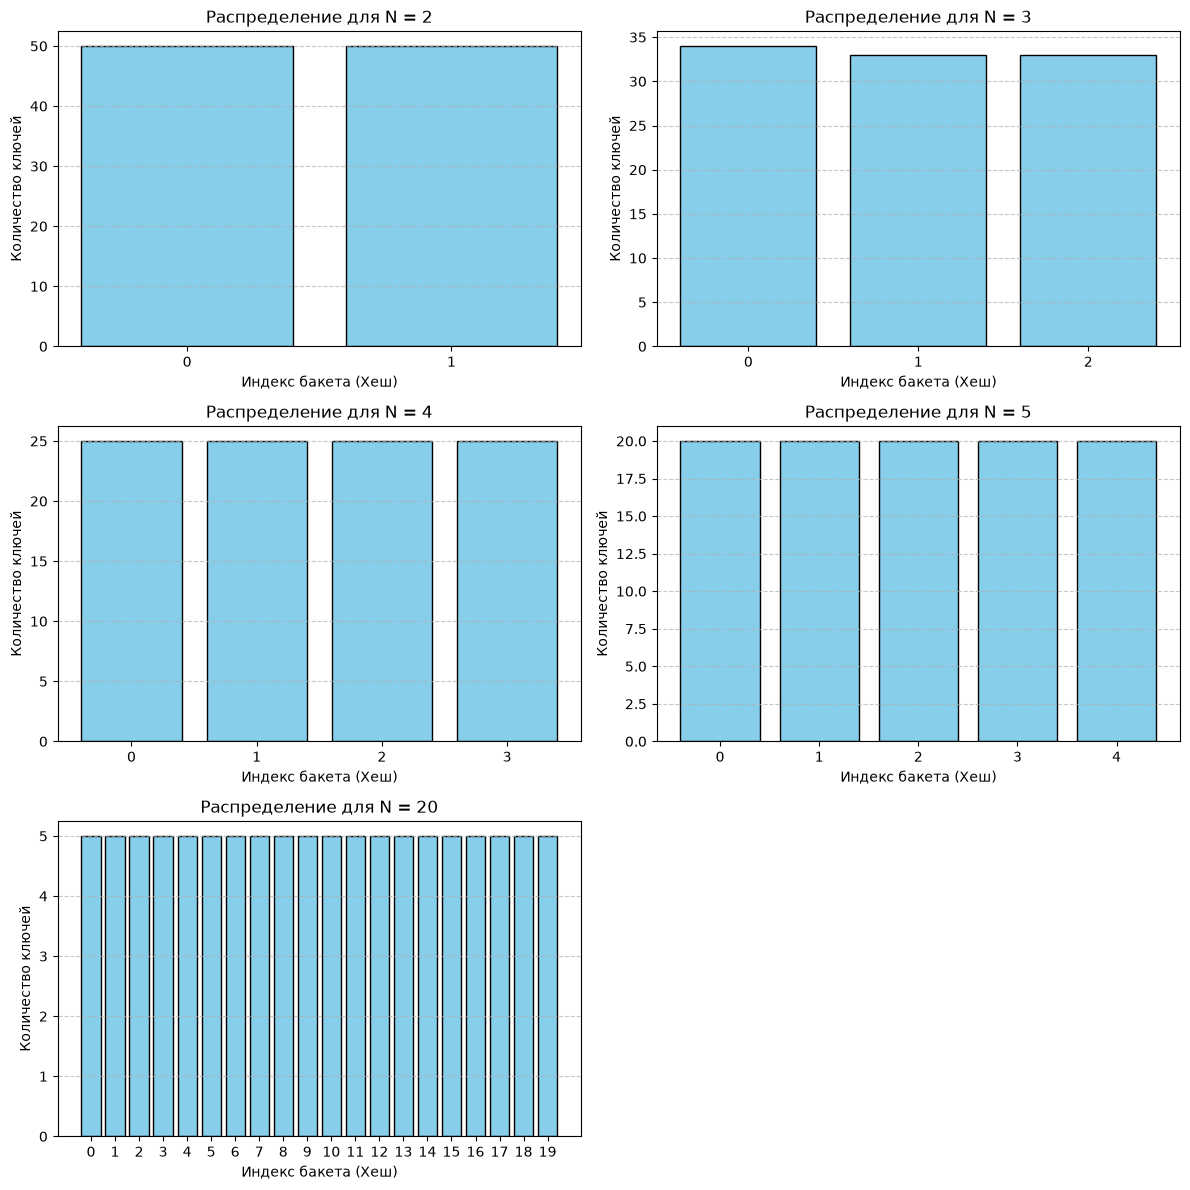

Результаты распределения по бакетам:
{2: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1], 3: [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0], 4: [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3], 5: [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4

In [ ]:
visualise_hash_fun([2, 3, 4, 5, 20])

In [25]:
# 706. Design HashMap

In [26]:
from typing import Optional

class ListNode:
    def __init__(self,key=1, val=-1, next = None):
        self.key = key
        self.val = val
        self.next = next

class LinkedList:
    def __init__(self):
        self.head = ListNode()

    def get(self, key):
        cur = self.head.next
        while cur:
            if cur.key == key:
                return cur.val
            cur = cur.next

        return -1

    def put(self, key, val):
        cur = self.head
        while cur.next:
            if cur.next.key == key:
                cur.next.val = val
                return
            cur = cur.next
        
        cur.next = ListNode(key, val)

    def remove(self, key):
        cur = self.head

        while cur.next:
            if cur.next.key == key:
                cur.next = cur.next.next
                return
            cur = cur.next


class MyHashMap:

    def __init__(self):
        self.size = 1000
        self.buckets = [LinkedList() for _ in range(self.size)]

    def hash_(self, key):
        return key % self.size

    def put(self, key: int, value: int) -> None:
        index = self.hash_(key)
        self.buckets[index].put(key, value)
                
    def get(self, key: int) -> int:
        index = self.hash_(key)
        result = self.buckets[index].get(key)
        return result

    def remove(self, key: int) -> None:
        index = self.hash_(key)
        self.buckets[index].remove(key)
        


# Your MyHashMap object will be instantiated and called as such:
# obj = MyHashMap()
# obj.put(key,value)
# param_2 = obj.get(key)
# obj.remove(key)